In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [34]:
park_agg = pd.read_csv("../data/clean/park_agg.csv")

park_agg['High_Crowding'] = (park_agg['Recreation Visits'] > park_agg['Recreation Visits'].median()).astype(int)
features = ['Concessioner Lodging','Concessioner Camping','Tent Campers','RV Campers','Backcountry','Miscellaneous Overnight Stays','Number of Activities','Entrance Fees']
target = 'High_Crowding'
display(park_agg[features].head())
display(park_agg[[target]].head())

,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
0,0.000000,104.825758,10320.848485,3754.424242,106.265152,698.704545,46.0,6.0
1,0.000000,0.000000,1339.030303,1406.000000,32.174242,457.840909,18.0,30.0
2,802.356061,2125.492424,325.030303,72.454545,192.409091,6.598485,21.0,30.0
3,2717.181818,616.053030,4288.750000,2258.462121,3197.219697,2354.234848,24.0,30.0
4,0.000000,0.000000,128.962121,0.000000,0.000000,238.113636,24.0,0.0


,High_Crowding
0,1
1,1
2,1
3,0
4,0


In [35]:
park_agg['High_Crowding'] =(park_agg['Recreation Visits'] >park_agg['Recreation Visits'].median()).astype(int)
park_agg.to_csv('../data/clean/park_agg_for_nn.csv', index=False)

In [36]:
X_train, X_test, y_train,y_test=train_test_split(park_agg[features],park_agg[target],test_size=0.25,random_state=12,stratify=park_agg[target])
display(pd.DataFrame(X_train).head())
display(pd.DataFrame(y_train).head())
display(pd.DataFrame(X_test).head())
display(pd.DataFrame(y_test).head())

,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
1,0.000000,0.000000,1339.030303,1406.0,32.174242,457.840909,18.0,30.0
45,0.000000,0.000000,0.000000,0.0,66.742424,0.000000,37.0,25.0
20,1054.886364,0.000000,58.219697,0.0,358.583333,992.893939,31.0,0.0
34,345.901515,0.000000,275.030303,0.0,356.113636,0.530303,23.0,0.0
51,506.825758,583.916667,0.000000,0.0,0.000000,2111.560606,31.0,0.0


,High_Crowding
1,1
45,0
20,0
34,0
51,0


,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
46,0.0,2126.30303,0.000000,0.000000,0.000000,0.000000,26.0,30.0
24,0.0,0.00000,2053.265152,1497.893939,36.151515,115.924242,35.0,0.0
30,0.0,0.00000,156.742424,2278.969697,0.000000,0.000000,20.0,0.0
5,0.0,0.00000,1377.848485,988.250000,138.363636,0.000000,26.0,30.0
33,0.0,0.00000,17376.303030,6848.090909,1340.234848,5600.818182,29.0,30.0


,High_Crowding
46,0
24,0
30,1
5,0
33,1


In [37]:
sc =StandardScaler()
X_train =sc.fit_transform(X_train)
X_test = sc.transform(X_test)
display(pd.DataFrame(X_train,columns=features).head())

,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
0,-0.386858,-0.256921,-0.333145,-0.175538,-0.497088,-0.212332,-1.224241,0.810378
1,-0.386858,-0.256921,-0.579446,-0.578080,-0.489011,-0.648262,0.461863,0.462169
2,-0.300744,-0.256921,-0.568737,-0.578080,-0.420819,0.297115,-0.070590,-1.278878
3,-0.358621,-0.256921,-0.528857,-0.578080,-0.421396,-0.647757,-0.780529,-1.278878
4,-0.345484,-0.178057,-0.579446,-0.578080,-0.504606,1.362246,-0.070590,-1.278878


In [38]:
clf = MLPClassifier(hidden_layer_sizes=(6,),activation='relu',solver='adam',learning_rate_init=0.001,max_iter=500,random_state=42,verbose=True)
clf.fit(X_train, y_train)

Iteration 1, loss = 0.84790119
Iteration 2, loss = 0.84393531
Iteration 3, loss = 0.83998843
Iteration 4, loss = 0.83606099
Iteration 5, loss = 0.83215342
Iteration 6, loss = 0.82826611
Iteration 7, loss = 0.82439949
Iteration 8, loss = 0.82055392
Iteration 9, loss = 0.81672980
Iteration 10, loss = 0.81292748
Iteration 11, loss = 0.80914805
Iteration 12, loss = 0.80544058
Iteration 13, loss = 0.80178741
Iteration 14, loss = 0.79815960
Iteration 15, loss = 0.79455673
Iteration 16, loss = 0.79097862
Iteration 17, loss = 0.78742516
Iteration 18, loss = 0.78390246
Iteration 19, loss = 0.78042216
Iteration 20, loss = 0.77696668
Iteration 21, loss = 0.77353595
Iteration 22, loss = 0.77012992
Iteration 23, loss = 0.76674900
Iteration 24, loss = 0.76339385
Iteration 25, loss = 0.76005917
Iteration 26, loss = 0.75674866
Iteration 27, loss = 0.75346233
Iteration 28, loss = 0.75020018
Iteration 29, loss = 0.74696219
Iteration 30, loss = 0.74374833
Iteration 31, loss = 0.74055856
Iteration 32, los

C:\Users\jenny\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(6,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [39]:
y_pred = clf.predict(X_test)

In [40]:
nn_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Percentage:", round(nn_accuracy * 100, 1),"%")

Accuracy Percentage: 46.7 %


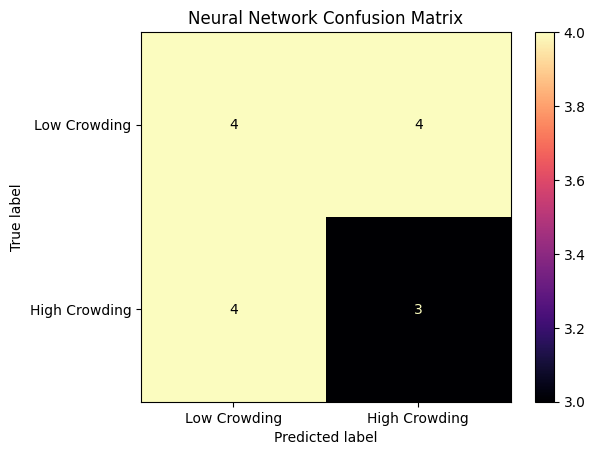

In [41]:
cm_nn = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn,display_labels=['Low Crowding', 'High Crowding'])
disp.plot(cmap='magma')
disp.ax_.set_title('Neural Network Confusion Matrix')
plt.savefig('../docs/images/nn_confusion_matrix.png',bbox_inches='tight')

In [42]:
loss_history = pd.DataFrame({'Epoch': range(1, len(clf.loss_curve_) + 1),'Training Loss': clf.loss_curve_})
last_five_epochs = loss_history.tail(5)
display(last_five_epochs)

,Epoch,Training Loss
495,496,0.291160
496,497,0.290962
497,498,0.290765
498,499,0.290570
499,500,0.290374


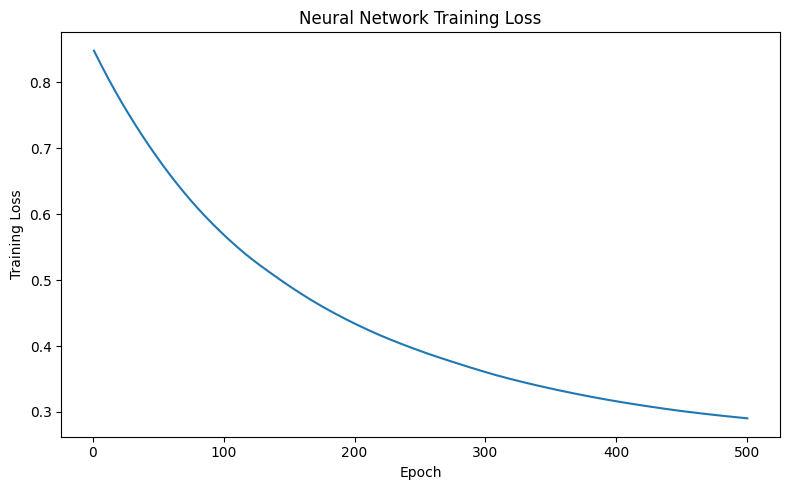

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(clf.loss_curve_) + 1),clf.loss_curve_)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Neural Network Training Loss')
plt.tight_layout()
plt.savefig('../docs/images/nn_training_loss.png',bbox_inches='tight')